# Cabo Verde Study Area Map
This notebook shows the codes used to draw a study area map of the Cabo Verde archipelago with:
- A **main map** showing all 10 islands with labels, a scale bar, and a north arrow
- An **inset locator map** showing Cabo Verde's position along the West African coast

### Imports & Backend Setup
- `plt.ioff()` disables Jupyter's auto-display, keeping `fig` alive across all cells
- `display` from IPython is used at the end to explicitly render the completed figure

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
from IPython.display import display

plt.ioff()  # Prevent Jupyter from auto-closing fig between cells
print("Imports complete")

Imports complete


### Helper Functions
Two reusable cartographic elements are defined here:

**`add_north_arrow`** — draws an N-arrow using `ax.annotate` with an arrowhead, positioned in axes-fraction coordinates so it stays fixed regardless of map extent.

**`add_scale_bar_km`** — calculates the degree-equivalent of a given kilometre distance at the map's mid-latitude (accounting for longitude compression with `cos(lat)`), then draws a simple tick bar with a label.

In [2]:
def add_north_arrow(ax, x=0.95, y=0.12, size=0.12):
    """Draw a north arrow at axes-fraction position (x, y)."""
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10,
        arrowprops=dict(arrowstyle="-|>", lw=1.0, color="black"),
        zorder=10,
    )

def add_scale_bar_km(ax, length_km=100, location=(0.10, 0.08)):
    """Draw a scale bar of length_km kilometres on the map."""
    x0, x1, y0, y1 = ax.get_extent(ccrs.PlateCarree())
    lat_mid = (y0 + y1) / 2.0
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat_mid))
    length_deg = float(length_km) / km_per_deg_lon

    lon_start = x0 + (x1 - x0) * float(location[0])
    lat       = y0 + (y1 - y0) * float(location[1])
    lon_end   = lon_start + length_deg

    ax.plot([lon_start, lon_end], [lat, lat],
            transform=ccrs.PlateCarree(), color="black", lw=1.6, zorder=10)
    ax.plot([lon_start, lon_start], [lat - 0.03, lat + 0.03],
            transform=ccrs.PlateCarree(), color="black", lw=1.6, zorder=10)
    ax.plot([lon_end, lon_end], [lat - 0.03, lat + 0.03],
            transform=ccrs.PlateCarree(), color="black", lw=1.6, zorder=10)
    ax.text((lon_start + lon_end) / 2.0, lat + 0.06,
            str(length_km) + " km",
            transform=ccrs.PlateCarree(), ha="center", va="bottom", fontsize=9, zorder=10)

print("Helper functions defined")

Helper functions defined


### Island Coordinates & Map Extents
- `islands` — dictionary of all 10 Cabo Verde islands with approximate centre coordinates (lon, lat)
- `cv_extent` — bounding box for the main map (western to eastern islands)
- `wa_extent` — wider bounding box for the inset locator (West Africa + Atlantic context)

In [3]:
islands = {
    "Santo Antao": (-25.17, 17.12),
    "Sao Vicente": (-25.00, 16.90),
    "Santa Luzia": (-24.75, 16.76),
    "Sao Nicolau": (-24.35, 16.62),
    "Sal":         (-22.94, 16.75),
    "Boa Vista":   (-22.80, 16.10),
    "Maio":        (-23.15, 15.21),
    "Santiago":    (-23.62, 15.10),
    "Fogo":        (-24.35, 14.95),
    "Brava":       (-24.70, 14.86),
}

cv_extent = [-26.3, -22.1, 14.4, 17.5]   # [west, east, south, north]
wa_extent = [-30,   10,     0,   32]      # wider West Africa inset

print(f"{len(islands)} islands loaded")
print(f"Main map extent : {cv_extent}")
print(f"Inset map extent: {wa_extent}")

10 islands loaded
Main map extent : [-26.3, -22.1, 14.4, 17.5]
Inset map extent: [-30, 10, 0, 32]


### Create Figure & Main Map Axes
- `fig.add_axes([left, bottom, width, height])` uses figure-fraction units, giving precise manual control over placement alongside the inset
- The main axes `ax` occupies ~70% of the figure width, leaving room for the inset on the right
- Ocean and land are layered using Natural Earth 10 m data with explicit `zorder` values to ensure correct draw order

In [4]:
fig = plt.figure(figsize=(8.4, 6.0))

# Main map — left portion of figure
ax = fig.add_axes([0.06, 0.06, 0.70, 0.88], projection=ccrs.PlateCarree())
ax.set_extent(cv_extent, crs=ccrs.PlateCarree())

# Background layers (zorder controls draw order)
ax.add_feature(cfeature.OCEAN.with_scale("10m"),    facecolor="#f7fbff", zorder=0)
ax.add_feature(cfeature.LAND.with_scale("10m"),     facecolor="#efefef", zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale("10m"),linewidth=0.9,       zorder=3)

# Country borders (thin, for geographic context)
admin0_path = shapereader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")
ax.add_geometries(
    shapereader.Reader(admin0_path).geometries(),
    ccrs.PlateCarree(),
    facecolor="none", edgecolor="#777777", linewidth=0.35, zorder=2
)

print("Figure and main axes created")

Figure and main axes created


### Gridlines & Island Labels
- Gridlines are drawn with dashed light-grey lines; top and right labels are suppressed for a clean look
- Each island gets a small blue dot marker and a text label offset slightly so it doesn't overlap the point

In [5]:
# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="#9aa0a6", alpha=0.6, linestyle="--")
gl.top_labels   = False
gl.right_labels = False
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

# Island markers and labels
for name, (lon, lat) in islands.items():
    ax.plot(lon, lat, marker="o", ms=2.8, color="#1f77b4",
            transform=ccrs.PlateCarree(), zorder=6)
    ax.text(lon + 0.07, lat + 0.03, name, fontsize=8.5, color="#111111",
            transform=ccrs.PlateCarree(), zorder=7)

print("Gridlines and island labels added")

Gridlines and island labels added


### Scale Bar & North Arrow
- Scale bar is placed at 10% from the left and 8% from the bottom of the map extent
- North arrow is placed at 95% from the left and 12% from the bottom in axes-fraction coordinates

In [6]:
add_scale_bar_km(ax, length_km=100, location=(0.10, 0.08))
add_north_arrow(ax, x=0.95, y=0.12, size=0.12)

print("Scale bar and north arrow added")

Scale bar and north arrow added


### Inset Locator Map
- A second axes `ax_in` is placed in the upper-right corner using figure-fraction coordinates
- It shows the wider West Africa region with a **red dot** marking Cabo Verde's position
- A **red bounding box** matching `cv_extent` is drawn to show exactly which area the main map covers
- Tick labels are removed to keep the inset compact and uncluttered

In [7]:
# Inset axes — upper right
ax_in = fig.add_axes([0.74, 0.60, 0.24, 0.32], projection=ccrs.PlateCarree())
ax_in.set_extent(wa_extent, crs=ccrs.PlateCarree())

# Background
ax_in.add_feature(cfeature.OCEAN.with_scale("10m"),     facecolor="#f7fbff", zorder=0)
ax_in.add_feature(cfeature.LAND.with_scale("10m"),      facecolor="#efefef", zorder=1)
ax_in.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.5,       zorder=2)
ax_in.add_geometries(
    shapereader.Reader(admin0_path).geometries(),
    ccrs.PlateCarree(),
    facecolor="none", edgecolor="#888888", linewidth=0.25, zorder=2
)

# Red dot marking Cabo Verde
cv_center = (-24.0, 16.0)
ax_in.plot(cv_center[0], cv_center[1], marker="o", ms=4.5, color="#d62728",
           transform=ccrs.PlateCarree(), zorder=4)
ax_in.text(cv_center[0] + 1.2, cv_center[1] - 0.5, "Cabo Verde",
           fontsize=8, transform=ccrs.PlateCarree(), zorder=4)

# Bounding box matching the main map extent
ax_in.plot(
    [cv_extent[0], cv_extent[1], cv_extent[1], cv_extent[0], cv_extent[0]],
    [cv_extent[2], cv_extent[2], cv_extent[3], cv_extent[3], cv_extent[2]],
    color="#d62728", lw=1.0, transform=ccrs.PlateCarree(), zorder=4
)

ax_in.set_xticks([])
ax_in.set_yticks([])

print("Inset locator map added")

Inset locator map added


### Save & Display
- `fig.savefig()` saves the specific figure object built across all cells (not `plt.savefig()` which may grab a blank figure)
- `display(fig)` explicitly renders it in the notebook output

Saved to Downloads/cabo_verde_study_area.png


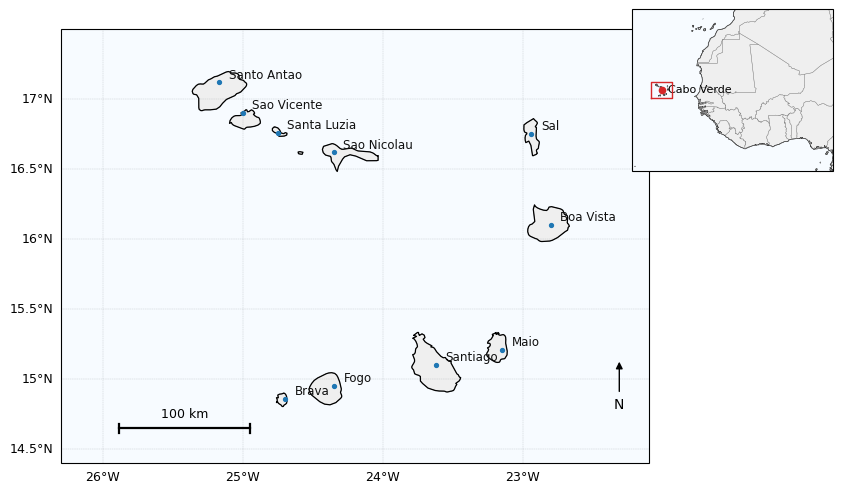

In [8]:
fig.savefig(
    r"C:\Users\LENOVO\Downloads\cabo_verde_study_area.png",
    dpi=200, bbox_inches="tight"
)
print("Saved to Downloads/cabo_verde_study_area.png")

display(fig)  # Render the figure built across all cells